# Python Notebook to Scale and Combine images

In [7]:
# importing all the relevant libraries 
import numpy as np
import astroalign as aa
import matplotlib.pyplot as plt
import ccdproc
import astropy.io.fits as fits
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
import gc
gc.enable()

In [8]:
# ignoring warnings
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("astropy").setLevel(logging.WARNING)

#### Ensure 01_data_proc_aligning.ipynb has completed running before executing this notebook

#### Select Star Positions
Once aligned images are generated, open the images on ds9 using bash. Set scale limits and colour so stars are easier to identify. Select five unsaturated stars using the region tool. Save those regions as a txt file in the folder "star_fluxes" with file name "regions_ds9.txt". Set the aperture radius below

In [9]:
# Get positions of reference stars
positions = []
with open("star_fluxes/regions_ds9.txt", "r") as f:
    for line in f:
        if line.startswith("circle"):
            values = line.split("(")[1].split(")")[0]
            x, y, _ = values.split(",")
            positions.append((float(x), float(y)))

# Aperture radius
apr = 8.3

# Number of images excluded for each band - get from background plot
imgs_excl = [42, 44, 38]
num_img = 282

# Reference Image for Scaling - update after scaling plots created
ref_scl = [60, 60, 60]

# folder name with images
im_dir = "aligned_images/"

## Python Functions

### Band Selector Variable Assignments

In [10]:
def band_sel(fidx):
    # Band Variables
    bands = ["b", "g", "r"]
    band = bands[fidx]
    fn_name = '*_'+band + '.fit'
    refidx = ref_scl[fidx]
    return fn_name, refidx, band

### Scaling Function

In [11]:
def scaling(fidx):

    # extract variables and details for the given band
    num_excl = imgs_excl[fidx]
    fn_name, refidx, band = band_sel(fidx)
    print(f"\n-------------- Begin Processing of", band, "Images --------------")

    print("Beginning Image Scaling")
    # importing aligned images
    images = ccdproc.ImageFileCollection(im_dir+band+"/", glob_include=fn_name)
    scim = []
    for fn in images.files_filtered():
        scim.append(CCDData.read(im_dir+band+"/"+ fn, unit = "adu")) 

        # Update scim with the correct time meta data
        times = scim[-1].header['DATE-OBS']         # Get the time
        t = Time(times, format='isot', scale='utc') # Read the time from UTC format
        scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')      
    print("Images Loaded: ", len(scim))

    # conducting aperture photometry on the selected stars
    apertures = CircularAperture(positions, r=apr)
    phot_tables=[]
    for idx, thisimage in enumerate(scim):                                       
        phot_tables.extend([aperture_photometry(thisimage, apertures)]) 

    # saving star fluxes to txt file
    star_fluxes = np.array([p['aperture_sum'].value for p in phot_tables])
    np.savetxt("star_fluxes/"+band+"_star_fluxes.csv", star_fluxes, delimiter=",")        

    # creating scaling plots for each star ---------------------------------
    plt.rcParams['font.family'] = 'Times New Roman'

    x = np.arange(num_excl, num_img) # image numbers
    fig, ax = plt.subplots(figsize=(10, 5))

    window = 15 # moving average window
    clrs = plt.cm.tab10(np.linspace(0, 1, 5))
    for i in range(star_fluxes.shape[1]):
        # Plot raw data
        ax.plot(x, star_fluxes[:, i], marker='o', linestyle="", markersize=1.5, color=clrs[i], label=f"Star {i+1}")

        # Compute moving average
        moving_avg = np.convolve(star_fluxes[:, i], np.ones(window)/window, mode='valid')
        x_avg = x[:len(moving_avg)]

        # Plot moving average line
        ax.plot(x_avg, moving_avg, linewidth=2, color=clrs[i])

    # Labels
    ax.set_xlabel("Image number")
    ax.set_ylabel("Aperture Flux (ADU)")
    ax.set_title(f"NGC 2547 {band}-band\nStar Fluxes")

    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(np.arange(x[0], x[-1], 14))
    plt.tight_layout()
    
    plt.savefig("star_fluxes/star_flux_"+band+".png")

    print(f"Image scaling data saved\n")

    return phot_tables, scim

### Combine Function

In [12]:
def combine(fidx):
    phot_tables, scim = scaling(fidx)
    
    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print("Beginning Image Combining")

    # determining scaling multiplier for each image
    scaling_m = []
    for idx, thisimage in enumerate(scim):                                                                  
        # scaling each image with the reference image
        m = np.ma.median(phot_tables[refidx]['aperture_sum'] / phot_tables[idx]['aperture_sum'])    
        scaling_m.append(round(m, 6))

        # normalising adu counts with reference image
        scim[idx] = scim[idx].multiply(m * u.adu)                                                   
    np.savetxt("star_fluxes/"+band+"_scaling_mult.txt", scaling_m)

    print(f"Max scaling multiplier: {np.max(scaling_m):.4f}")
    print(f"Min scaling multiplier: {np.min(scaling_m):.4f}")

    # Median combining image 
    sci_median = ccdproc.combine(scim, method = 'median',dtype = np.float32,       
                                minmax_clip = True, minmax_clip_min = -500)
    sci_median.write(band+"_NGC_2547_med.fits", overwrite=True)

    # clearing memory
    del(scim)
    collected = gc.collect()
    print('Check garbage collection', collected)

    # Plot median combined image and save as png
    fig, ax = plt.subplots(figsize = (5,10))
    scim = CCDData.read(band+"_NGC_2547_med.fits", unit="adu")                 
    p1 = np.percentile(scim, 1)
    p99 = np.percentile(scim, 99)
    plt.imshow(scim, cmap='magma', vmin=p1, vmax=p99, origin = "lower") 
    plt.colorbar(label='Pixel Value (ADU)')
    plt.title(f"NGC 2547 {band}-band Combined FITS image")

    print("png Image saved")
    plt.savefig("combined_images/"+band+"_med.png")


    print(band,f"Images Combined!\n")

## Executing Code
This executions completes the scaling and combining for all bands. 


-------------- Begin Processing of b Images --------------
Beginning Image Scaling
Images Loaded:  240
Image scaling data saved

Beginning Image Combining
Max scaling multiplier: 2.3565
Min scaling multiplier: 0.9051
Check garbage collection 34714
png Image saved
b Images Combined!


-------------- Begin Processing of g Images --------------
Beginning Image Scaling
Images Loaded:  238
Image scaling data saved

Beginning Image Combining
Max scaling multiplier: 2.3260
Min scaling multiplier: 0.9697
Check garbage collection 1448
png Image saved
g Images Combined!


-------------- Begin Processing of r Images --------------
Beginning Image Scaling
Images Loaded:  244
Image scaling data saved

Beginning Image Combining
Max scaling multiplier: 2.1153
Min scaling multiplier: 0.8009
Check garbage collection 1496
png Image saved
r Images Combined!



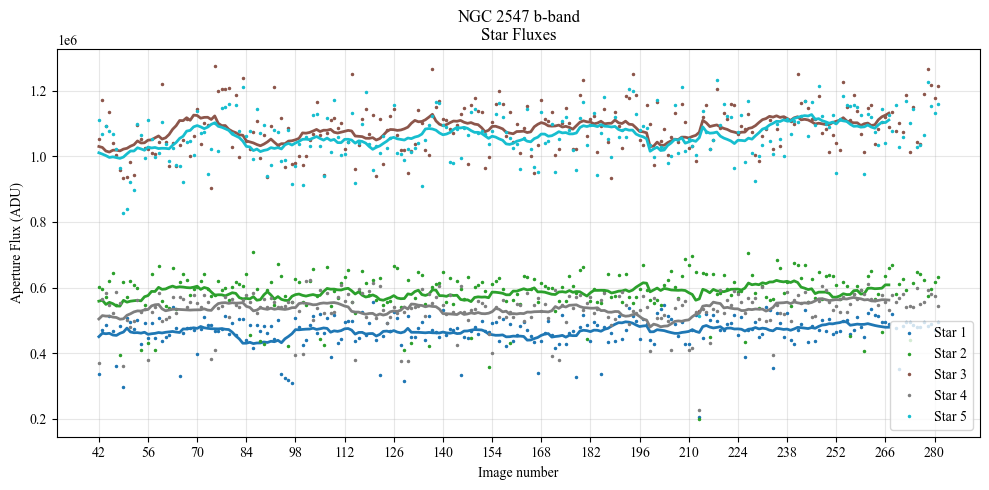

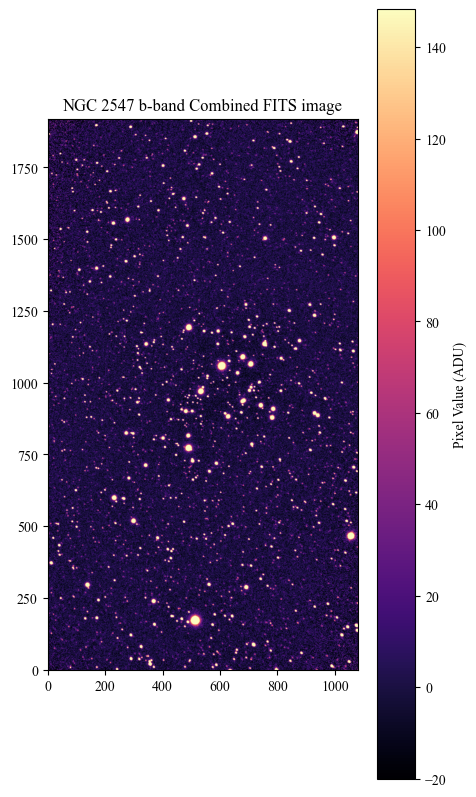

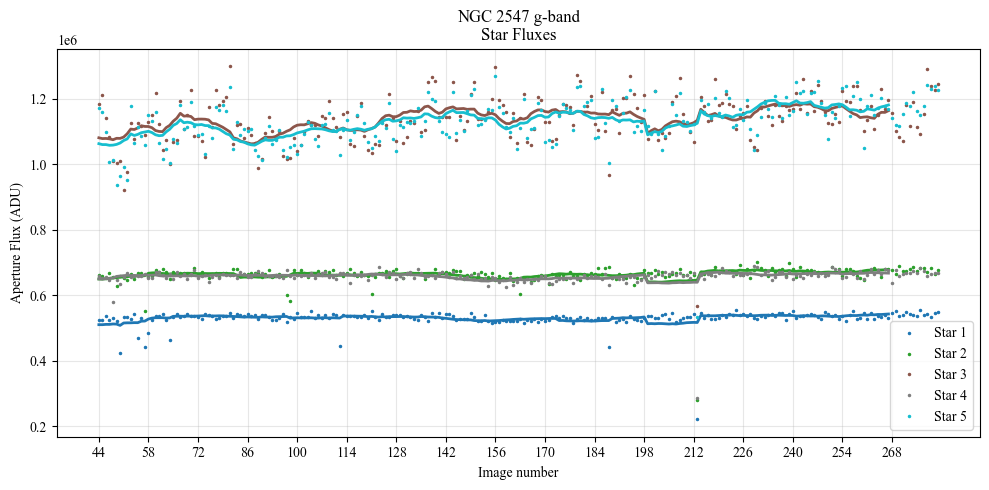

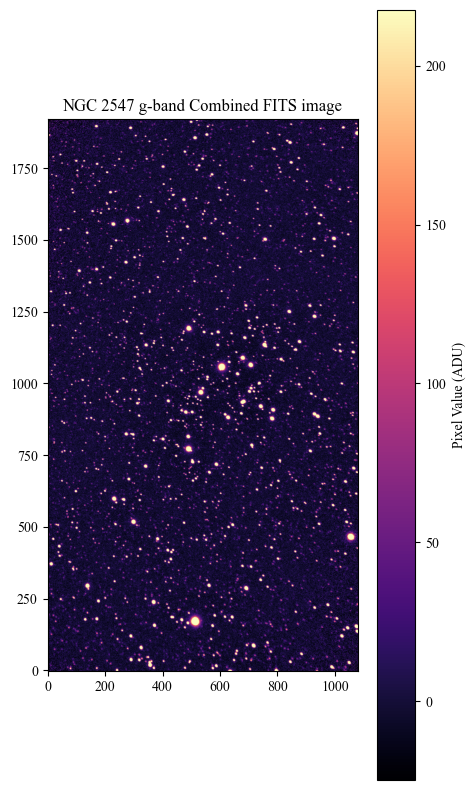

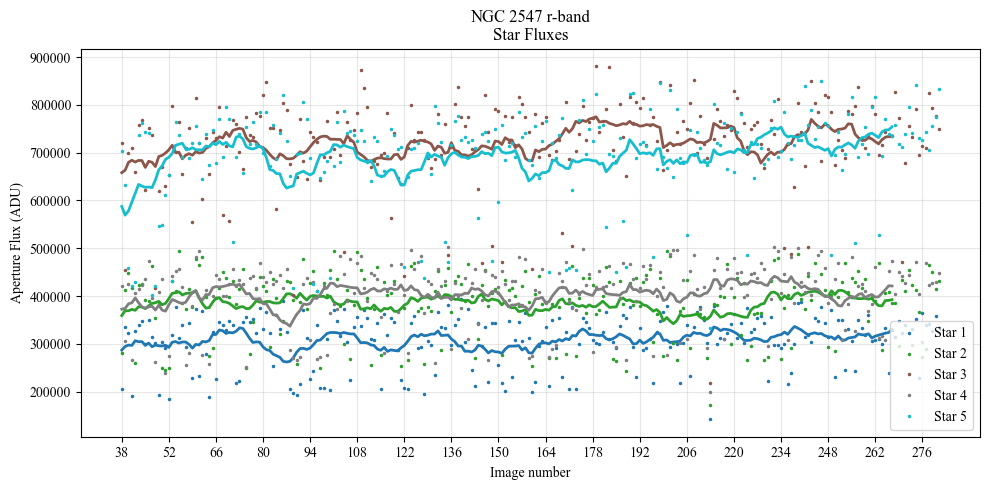

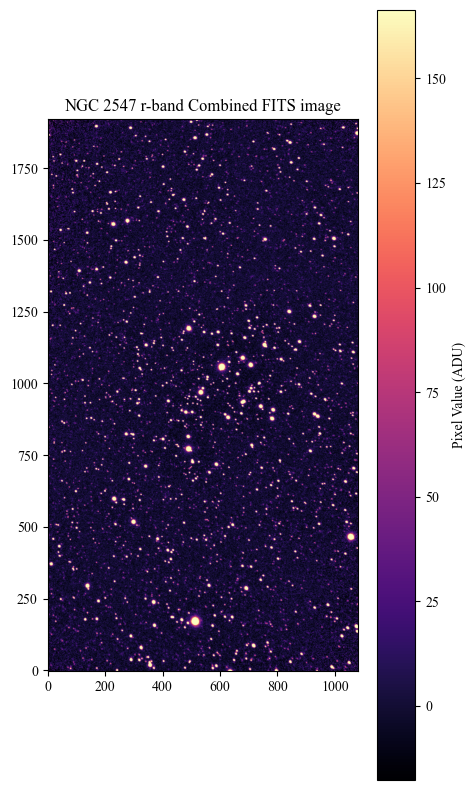

In [15]:
for fidx in list(range(3)):
    combine(fidx)

### Cropping Image

Since the image captures stars beyond the cluster, the final image will be cropped for y pixels lower than 600 and higher than 1300

png Image saved
png Image saved
png Image saved


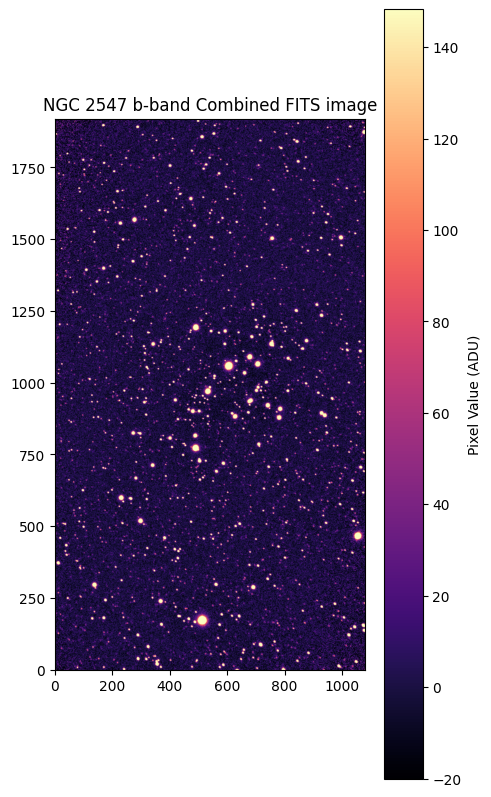

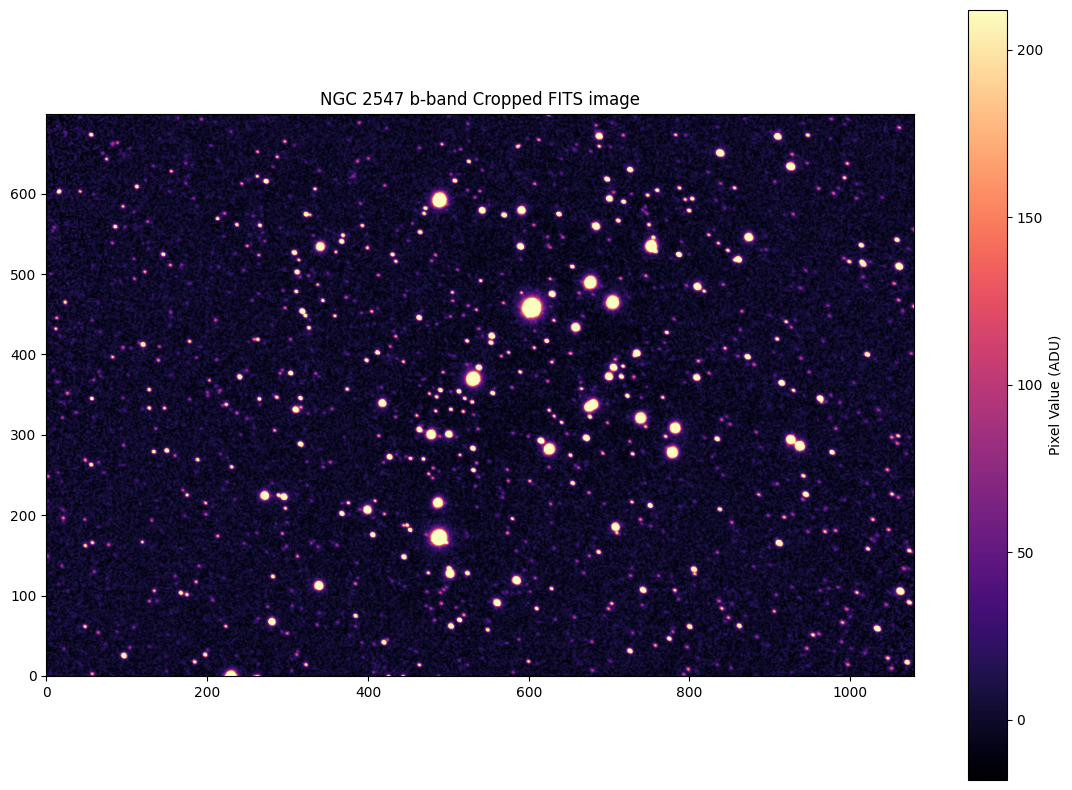

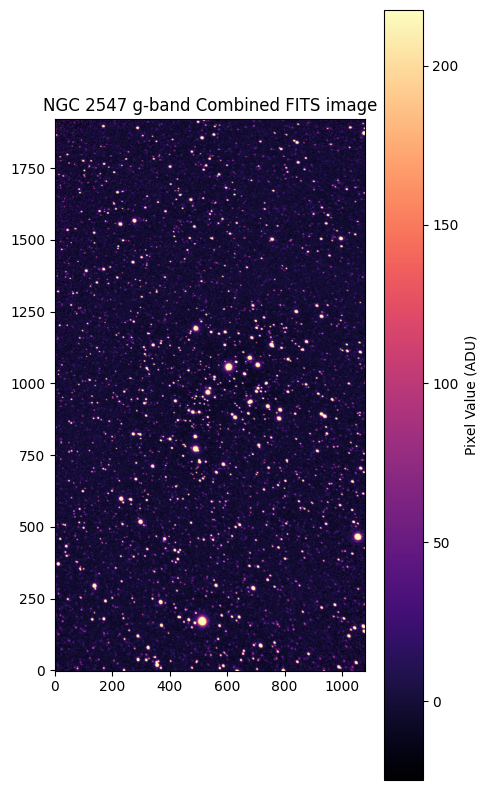

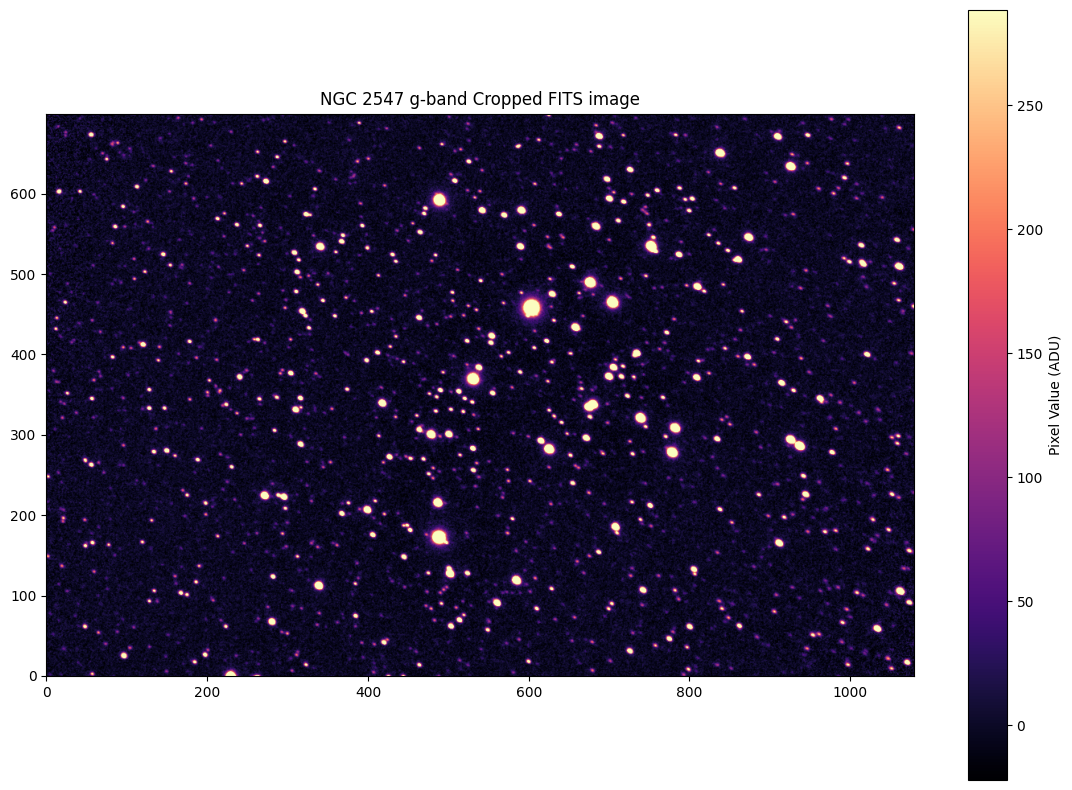

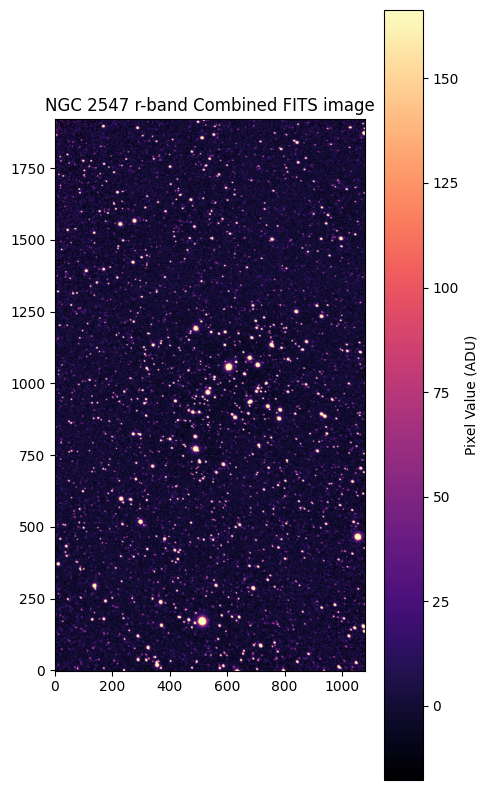

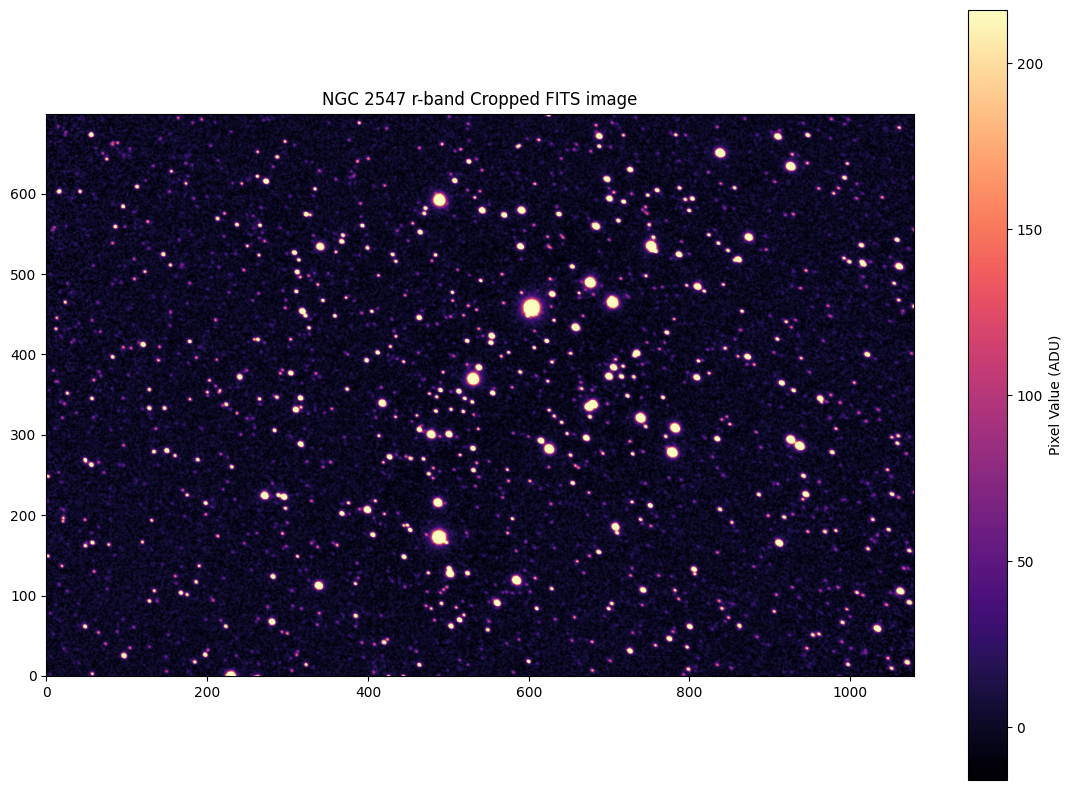

In [15]:
# import images
for fidx in list(range(3)):
    fn_name, refidx, band = band_sel(fidx)
    fn_name = band + "_NGC_2547_med.fits"
    img = ccdproc.ImageFileCollection("", glob_include=fn_name)
    scim = CCDData.read(fn_name, unit = "adu")

    # Update scim with the correct time meta data
    times = scim.header['DATE']         # Get the time
    t = Time(times, format='isot', scale='utc') # Read the time from UTC format
    scim.header['MJD-OBS'] = (float(t.mjd), 'MJD')

    # display loaded image
    fig, ax = plt.subplots(figsize = (5,10))
    p1 = np.percentile(scim, 1)
    p99 = np.percentile(scim, 99)
    plt.imshow(scim, cmap='magma', vmin=p1, vmax=p99, origin = "lower") 
    plt.colorbar(label='Pixel Value (ADU)')
    plt.title(f"NGC 2547 {band}-band Combined FITS image")

    # crop image
    scim = scim[600:1300][:]
    fig, ax = plt.subplots(figsize = (14,10))
    p1 = np.percentile(scim, 1)
    p99 = np.percentile(scim, 99)
    plt.imshow(scim, cmap='magma', vmin=p1, vmax=p99, origin = "lower") 
    plt.colorbar(label='Pixel Value (ADU)')
    plt.title(f"NGC 2547 {band}-band Cropped FITS image")

    # write cropped image to FITS file
    scim.write(band+"_NGC_2547_cropped.fits", overwrite=True)

    # save cropped image
    print("png Image saved")
    plt.savefig("combined_images/"+band+"_med_cropped.png")

#### Updating WCS to Green-band image

Before running code ensure the wcs files exists for the given image

In [28]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits
from astropy.wcs import WCS

# importing combined image
fn = "g_NGC_2547_cropped.fits"
g_combined = CCDData.read(fn, unit="adu")
print("Loaded g_combined successfully")
print(g_combined.header)

fn_wcs = "wcs_headers/wcs_g.fits"
#wcs_header = fits.open(fn_wcs)
wcs = WCS(fn_wcs)
print(wcs)

# Add WCS to original FITS file
with fits.open(fn, mode='update') as hdul:
    hdul[0].header.update(wcs.to_header())
    hdul.flush()

fn = "g_NGC_2547_cropped.fits"
g_combined = CCDData.read(fn, unit="adu")
print(g_combined.header)


Loaded g_combined successfully
SIMPLE  =                    T / Standard FITS file                             BITPIX  =                  -32 / ASCII or bytes array                           NAXIS   =                    2 / Minimal header                                 NAXIS1  =                 1080                                                  NAXIS2  =                  700                                                  EXTEND  =                    T / There may be FITS ext                          BUNIT   = 'adu     '                                                            IMAGEW  =                 1080 / Image width,  in pixels.                       IMAGEH  =                  700 / Image height, in pixels.                       DATE    = '2026-05-15T03:13:46' / Date this file was created.                   MJD-OBS =   61171.434212962966 / MJD                                            HISTORY Created by the Astrometry.net suite.                                    HISTORY F

In [ ]:
# confirming that the image has been updated with the correct header
wcs = WCS(fits.getheader(fn))
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 122.353311568 -48.8902271055
CRPIX : 587.693748474 -116.964008331
PC1_1 PC1_2  : -0.000595693031779 0.000280247364189
PC2_1 PC2_2  : -0.000281119408085 -0.000596031924072
CDELT : 1.0 1.0
NAXIS : 1080  700
